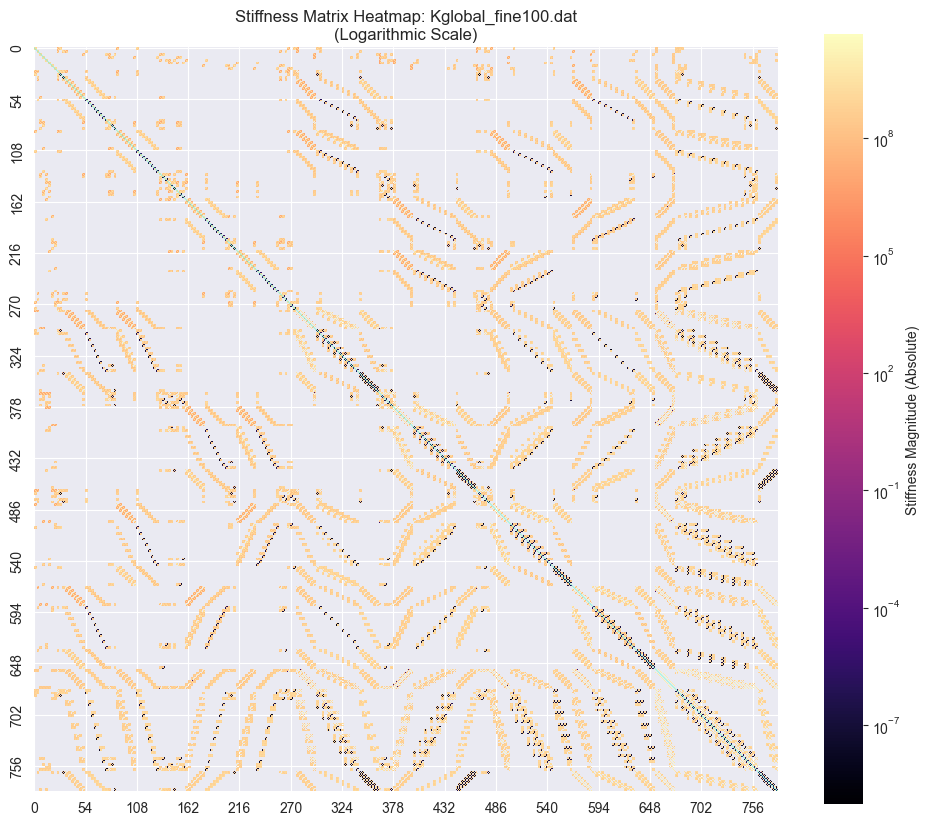

DIAG/OFF-DIAG RATIO: 120.53


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
from scipy.sparse import coo_matrix

# Load data (keeping your logic)
os.chdir(r"C:\Calculix\ccx_2.23_wsl\Stiffness matrices")
filename = "Kglobal_fine100.dat"
data = np.loadtxt(filename)
i, j, v = data[:, 0].astype(int) - 1, data[:, 1].astype(int) - 1, data[:, 2]

ndof = int(max(i.max(), j.max()) + 1)
K_ut = coo_matrix((v, (i, j)), shape=(ndof, ndof)).tocsr()
K_sparse = K_ut + K_ut.T - coo_matrix((K_ut.diagonal(), (range(ndof), range(ndof))), shape=(ndof, ndof)).tocsr()
K_abs = np.abs(K_sparse.toarray())

# --- THE FIX ---
# To make the diagonal "pop" and prove it's the highest value:
vmax = K_abs.max()
vmin = K_abs[K_abs > 0].min()

plt.figure(figsize=(12, 10))

# We use 'viridis' or 'inferno' which have better contrast for the diagonal
# and we disable the grid lines for the main plot to prevent 'color bleeding'
ax = sns.heatmap(K_abs,
            norm=LogNorm(vmin=vmin, vmax=vmax),
            cmap='magma',
            square=True,
            xticklabels=54, yticklabels=54, # Cleaner axis
            cbar_kws={'label': 'Stiffness Magnitude (Absolute)'})

# Manually highlight the diagonal to show the "Higher Ups" it is dominant
plt.plot([0, ndof], [0, ndof], color='cyan', lw=0.5, alpha=0.5, label='Diagonal Path')

plt.title(f"Stiffness Matrix Heatmap: {filename}\n(Logarithmic Scale)")
plt.show()

# Verification check for the meeting
diag_mean = np.mean(np.diag(K_abs))
off_diag_mean = (np.sum(K_abs) - np.sum(np.diag(K_abs))) / (ndof**2 - ndof)
print(f"DIAG/OFF-DIAG RATIO: {diag_mean / off_diag_mean:.2f}")